In [1]:
!pip install openpyxl

# Customer Segmentation Using RFM Analysis and K-Means Clustering

## Project Objective

The objective of this project is to segment customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

RFM analysis evaluates customers based on:

- Recency: How recently a customer made a purchase
- Frequency: How often a customer purchases
- Monetary: How much a customer spends

K-Means clustering will then be applied to these behavioural features to identify groups of customers with similar purchasing patterns.

## Business Goal

The goal is to identify meaningful customer segments and recommend appropriate marketing strategies for each segment.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

sns.set_theme(style="whitegrid")

In [3]:
import pandas as pd
df = pd.read_excel("Online Retail.xlsx")
print(df.shape)

(541909, 8)


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df["CustomerID"].isnull().sum()

np.int64(135080)

In [11]:
df = df.dropna(subset=["CustomerID"])

In [12]:
df.shape

(406829, 8)

In [13]:
df.duplicated().sum()

np.int64(5225)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    392732
True       8872
Name: count, dtype: int64

In [17]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

In [18]:
(df["Quantity"] <= 0).sum()

np.int64(0)

In [19]:
(df["UnitPrice"] <= 0).sum()

np.int64(40)

In [20]:
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

In [21]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [22]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [23]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [24]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [25]:
df[[
    "Quantity",
    "UnitPrice",
    "TotalAmount"
]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [26]:
df.shape

(392692, 9)

In [27]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [28]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [29]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [30]:
average_purchase_value = (
    df.groupby("CustomerID")["TotalAmount"]
    .mean()
)

average_purchase_value.describe()

count     4338.000000
mean        68.381590
std       1467.918294
min          2.136970
25%         12.393196
50%         17.755000
75%         24.878950
max      77183.600000
Name: TotalAmount, dtype: float64

In [31]:
purchase_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

purchase_frequency.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

In [32]:
customer_lifetime_value = (
    df.groupby("CustomerID")["TotalAmount"]
    .sum()
)

In [33]:
customer_lifetime_value.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalAmount, dtype: float64

In [34]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

analysis_date

Timestamp('2011-12-10 12:50:00')

In [35]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [36]:
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
}, inplace=True)

In [37]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [38]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


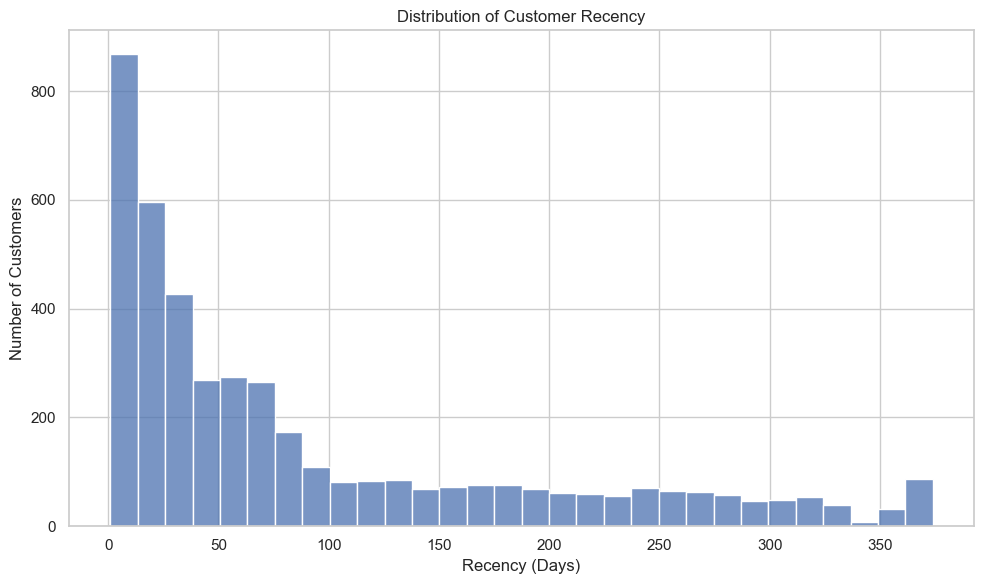

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(rfm["Recency"], bins=30)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The Recency distribution shows how recently customers interacted with the business. Customers with lower recency values made purchases more recently and are therefore more engaged than customers with high recency values.

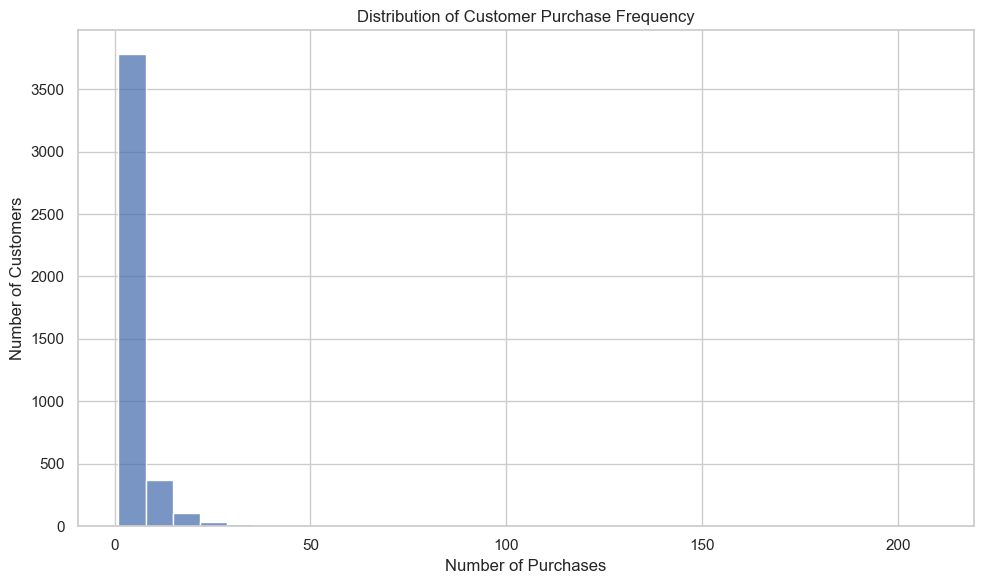

In [40]:

plt.figure(figsize=(10, 6))

sns.histplot(rfm["Frequency"], bins=30)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The frequency distribution shows that most customers make a relatively small number of purchases, while a smaller group purchases much more frequently. These frequent customers may represent an important group for loyalty and retention campaigns.

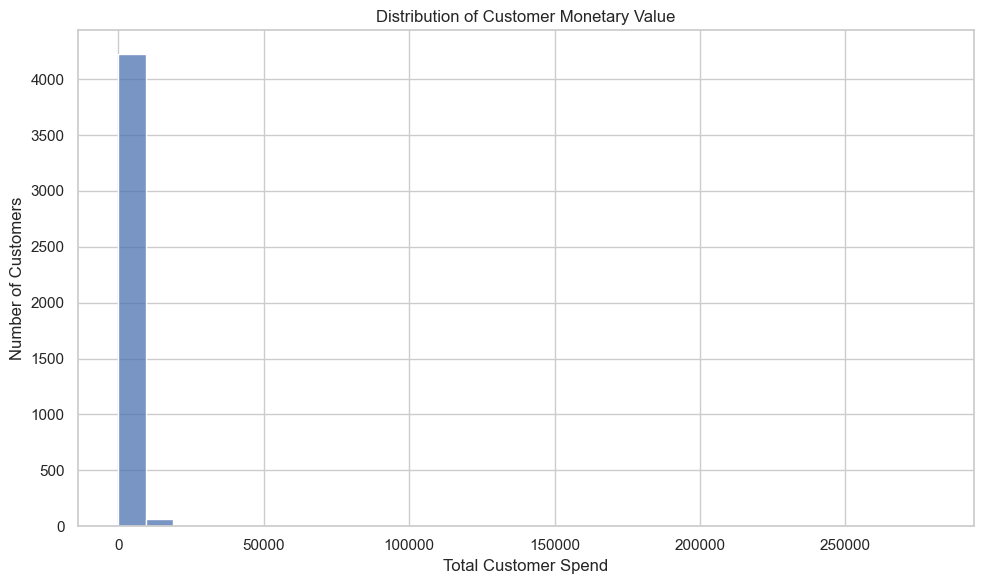

In [41]:
plt.figure(figsize=(10, 6))

sns.histplot(rfm["Monetary"], bins=30)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

Customer monetary value is unevenly distributed, with a smaller number of customers contributing substantially higher spending. These high-value customers should be considered carefully when developing retention strategies.

In [42]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

In [43]:
rfm_features = rfm[
    ["Recency", "Frequency", "Monetary"]
    ]

In [44]:
scaler = StandardScaler()

In [45]:
rfm_scaled = scaler.fit_transform(rfm_features)

In [46]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


## Why Standardize the RFM Features?

Recency, Frequency, and Monetary have very different numerical scales. For example, Recency is measured in days, Frequency is a transaction count, and Monetary is measured in currency.

StandardScaler transforms the variables to a comparable scale so that a variable with a larger numerical range does not dominate the K-Means clustering process.

In [47]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled_df)
    
    inertia.append(kmeans.inertia_)

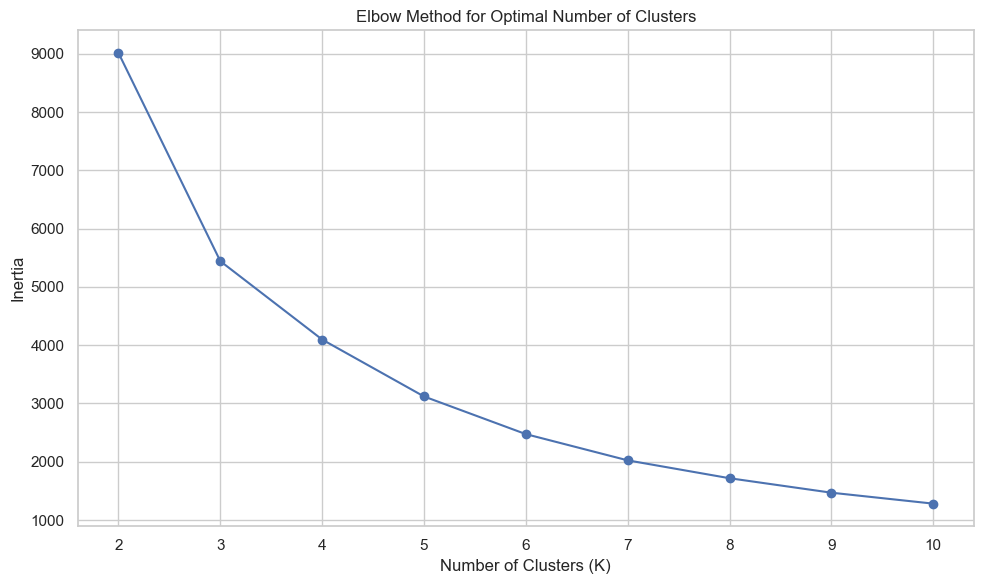

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.tight_layout()
plt.show()

In [49]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [50]:
rfm_scaled_df["Cluster"] = kmeans.fit_predict(
    rfm_scaled_df[
        ["Recency", "Frequency", "Monetary"]
    ]
)

In [51]:
rfm_scaled_df.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,2.334574,-0.425097,8.363010,3
12347.0,-0.905340,0.354417,0.251699,0
12348.0,-0.175360,-0.035340,-0.027988,0
12349.0,-0.735345,-0.425097,-0.032406,0
12350.0,2.174578,-0.425097,-0.190812,1


In [52]:
rfm["Cluster"] = rfm_scaled_df["Cluster"]

In [53]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [54]:
cluster_profile = (
    rfm.groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [58]:
cluster_names = {
    0: "At-Risk Customers",
    1: "Low-Value/Inactive Customers",
    2: "VIP Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

In [56]:
cluster_counts = rfm["Segment"].value_counts()

In [57]:
cluster_counts

Segment
At-Risk Customers               3054
Low-Value/Inactive Customers    1067
Loyal Customers                  204
VIP Customers                     13
Name: count, dtype: int64

In [61]:
cluster_counts = pd.DataFrame({"Counts": rfm["Segment"].value_counts(),
                                "Percentage":(rfm["Segment"].value_counts(normalize=True)*100).round(2)
                               })
cluster_counts

,Counts,Percentage
Segment,,
At-Risk Customers,3054,70.4
Low-Value/Inactive Customers,1067,24.6
Loyal Customers,204,4.7
VIP Customers,13,0.3


<Figure size 1000x600 with 0 Axes>

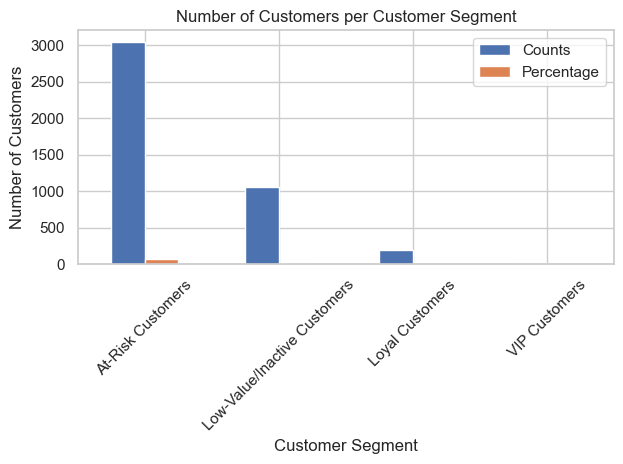

In [62]:
plt.figure(figsize=(10, 6))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers per Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation
The customer segments differ in size, indicating that customers do not have identical purchasing behaviours. The largest segment represents the most common customer behaviour, while smaller segments may contain more specialized high-value or at-risk customers.

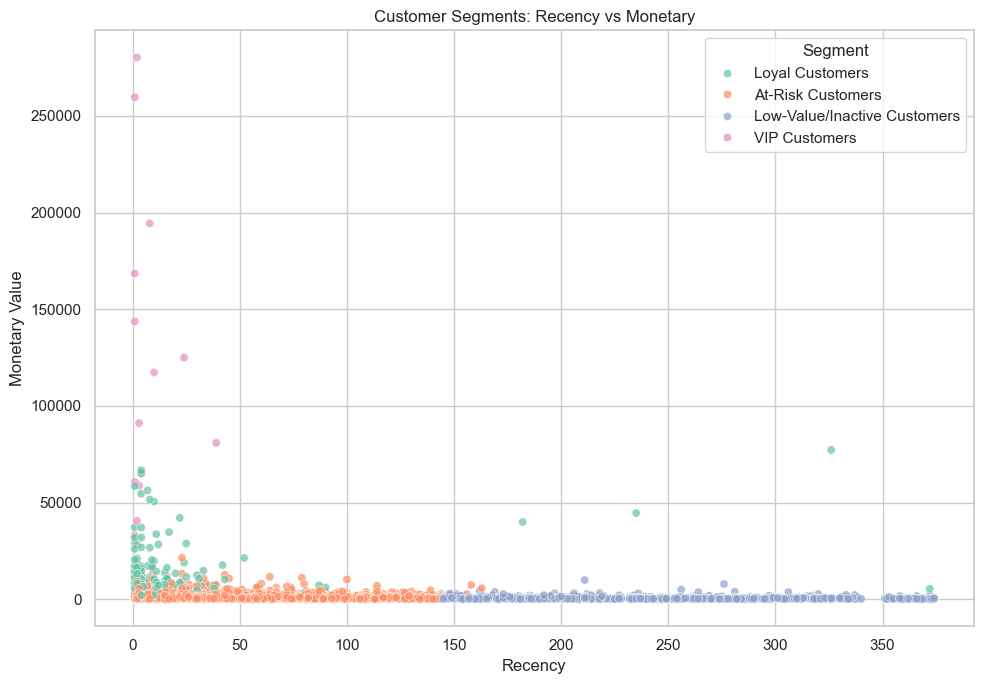

In [63]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

### Observation

The Recency-Monetary scatter plot shows differences in customer engagement and spending. Customers with lower Recency values have purchased more recently, while customers with higher Monetary values have generated greater historical revenue. The separation between segments demonstrates that customers differ substantially in both engagement and value.

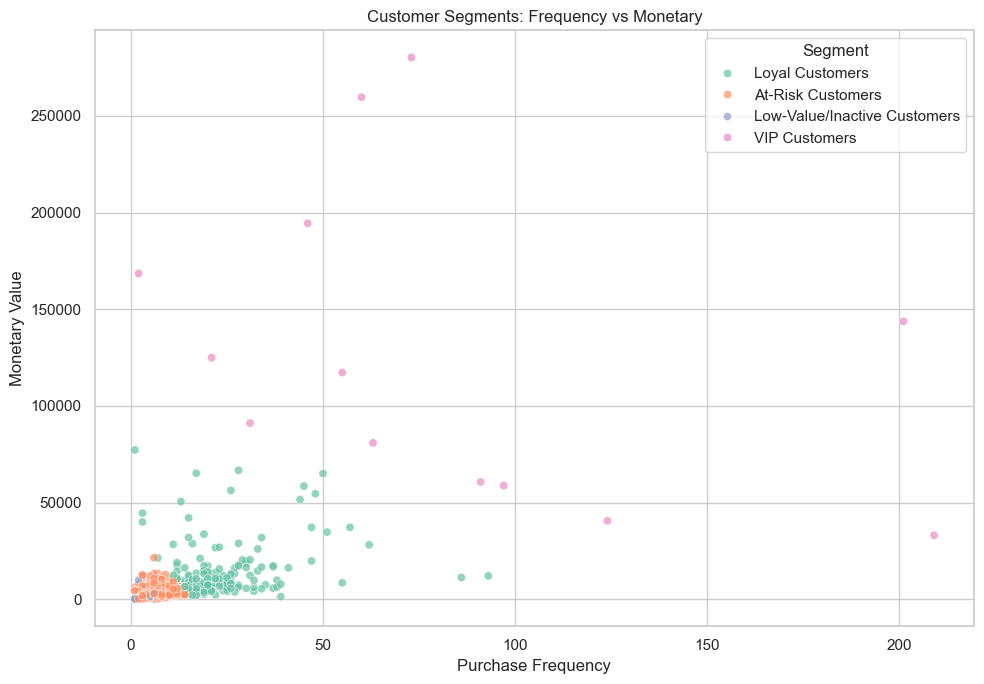

In [64]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

### Observation

The Frequency-Monetary visualization shows that customers who purchase more frequently tend to include some of the higher-value customers. However, frequency alone does not completely determine customer value because customers can make fewer purchases while still generating substantial revenue.

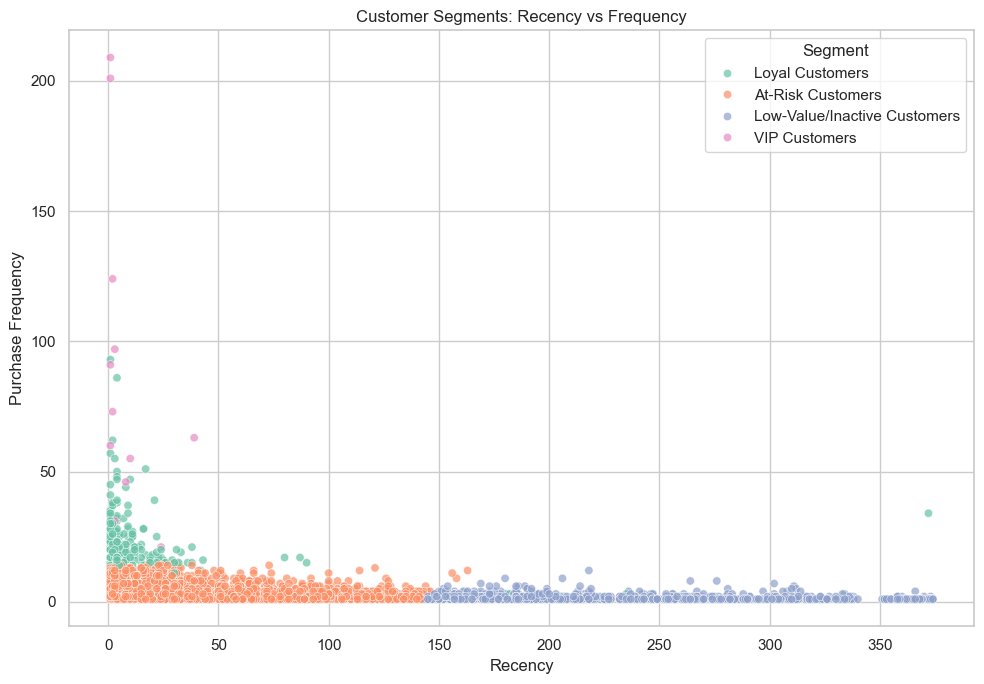

In [65]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Segment",
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency")
plt.ylabel("Purchase Frequency")

plt.tight_layout()
plt.show()

### Observation

The Recency-Frequency relationship highlights differences in customer engagement. Customers with low Recency and high Frequency demonstrate stronger ongoing engagement, while customers with high Recency and low Frequency may require reactivation campaigns.

In [66]:
final_profile = (
    rfm.groupby("Segment")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .agg(["mean", "median"])
    .round(2)
)

final_profile

Recency        Frequency          Monetary  \
                                mean median      mean median       mean   
Segment                                                                   
At-Risk Customers              43.70   32.0      3.68    3.0    1353.63   
Low-Value/Inactive Customers  248.08  243.0      1.55    1.0     478.85   
Loyal Customers                15.50    5.0     22.33   19.0   12690.50   
VIP Customers                   7.38    2.0     82.54   63.0  127187.96   

                                         
                                 median  
Segment                                  
At-Risk Customers                826.27  
Low-Value/Inactive Customers     310.26  
Loyal Customers                 7990.20  
VIP Customers                 117210.08

### VIP / High-Value Customers

These customers purchase recently, purchase frequently, and generate high monetary value.

**Marketing action:** Introduce VIP loyalty benefits, exclusive offers, early access to new products, and personalized recommendations. The objective should be retention rather than aggressive discounting.

### Loyal Customers

These customers purchase relatively frequently and demonstrate consistent engagement.

**Marketing action:** Use loyalty programs, rewards for repeat purchases, cross-selling, and product recommendations to increase their average order value and move them toward the highest-value segment.

### At-Risk Customers

These customers have previously demonstrated purchasing activity or value but have relatively high Recency.

**Marketing action:** Launch reactivation campaigns using personalized email offers, reminders, limited-time incentives, and recommendations based on previous purchases.

### Low-Value / Inactive Customers

These customers have low purchasing frequency and monetary value and may not have purchased recently.

**Marketing action:** Use low-cost automated campaigns and introductory promotions to test whether they can be reactivated. Marketing spending should remain controlled because their historical value is relatively low.

# Key Insights

1. Customers demonstrate substantially different purchasing behaviours based on recency, frequency, and monetary value.

2. RFM analysis provides a practical way to distinguish highly engaged customers from customers who may require reactivation.

3. Standardizing RFM variables before K-Means prevents variables with larger numerical scales from dominating the clustering process.

4. The Elbow Method provides a data-driven approach for selecting a suitable number of customer clusters.

5. High-value customers should receive retention-focused marketing, while at-risk customers require reactivation strategies.

6. Customer segmentation allows marketing resources to be allocated according to customer behaviour rather than treating all customers identically.

# Conclusion

This project used RFM analysis and K-Means clustering to segment customers according to their purchasing behaviour.

Recency, Frequency, and Monetary value were selected as the key behavioural features because they provide a practical representation of customer engagement and value. The RFM variables were standardized using StandardScaler before K-Means clustering was applied.

The Elbow Method was used to identify an appropriate number of clusters, after which customers were grouped into distinct behavioural segments. The cluster profiles demonstrated meaningful differences in customer recency, purchase frequency, and monetary contribution.

The segmentation provides a basis for targeted marketing. High-value customers should be prioritized for retention and loyalty initiatives, loyal customers should be encouraged to increase their spending, at-risk customers should receive reactivation campaigns, and low-value customers should be targeted with cost-efficient campaigns.

Overall, RFM-based K-Means clustering can help the business move from a one-size-fits-all marketing strategy toward targeted customer engagement based on measurable purchasing behaviour.

In [68]:
rfm.to_csv(
    "customer_rfm_segments.csv",
    index=True
)
print("saved_successfully")

saved_successfully
